<h1><font color='blue'>Análise de Sentimentos e Sistemas de Recomendação</font></h1>
<h2><b>Prática U2-T3-V2.2-Recomendação baseada em conteúdo personalizada</b></h2>


---

# Exemplo 1 - Recomendação baseada em conteúdo (personalizada)

## Lendo o dataset de filmes

In [27]:
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

### Carregar o arquivo de filmes

In [28]:
import pandas as pd
import numpy as np

movies = pd.read_csv('https://drive.google.com/uc?export=download&id=1yjGdaAJ5-YgIUx_1mLTcPqiZ8OI9TeqH', encoding='latin-1', low_memory=False)
movies['tags'] = movies['tags'].apply(lambda x: '' if isinstance(x,float) else x)
movies.set_index('movieId', inplace=True)
movies.head()

,title,genres,tags,tag_count,vote_count,vote_average,imdb_score
movieId,,,,,,,
1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,fun pixar,2,215,3.920930,3.894473
2,Jumanji,Adventure|Children|Fantasy,fantasy magic_board_game game robin_williams,4,110,3.431818,3.419009
3,Grumpier Old Men,Comedy|Romance,old moldy,2,52,3.259615,3.260033
4,Waiting to Exhale,Comedy|Drama|Romance,,0,7,2.357143,2.866377
5,Father of the Bride Part II,Comedy,pregnancy remake,2,49,3.071429,3.101070


### Carregar o arquivo de avaliações

In [29]:
ratings = pd.read_csv('https://drive.google.com/uc?export=download&id=1yCT7ximzeYFYHWAbJz3DO8_GL5raID74', encoding='latin-1', low_memory=False)
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [30]:
MAX_RATING = ratings['rating'].max()
MAX_RATING

5.0

## Recomendação baseada em conteúdo com ***user profile***

A ideia do ***user profile*** é traçar o perfil de um usuário, considerando as classificações realizadas por ele para descobrir o seu ***gosto***, e depois usar estas informações para estimar a classificação de filmes ainda não vistos e encontrar recomendações ainda mais personalizadas.

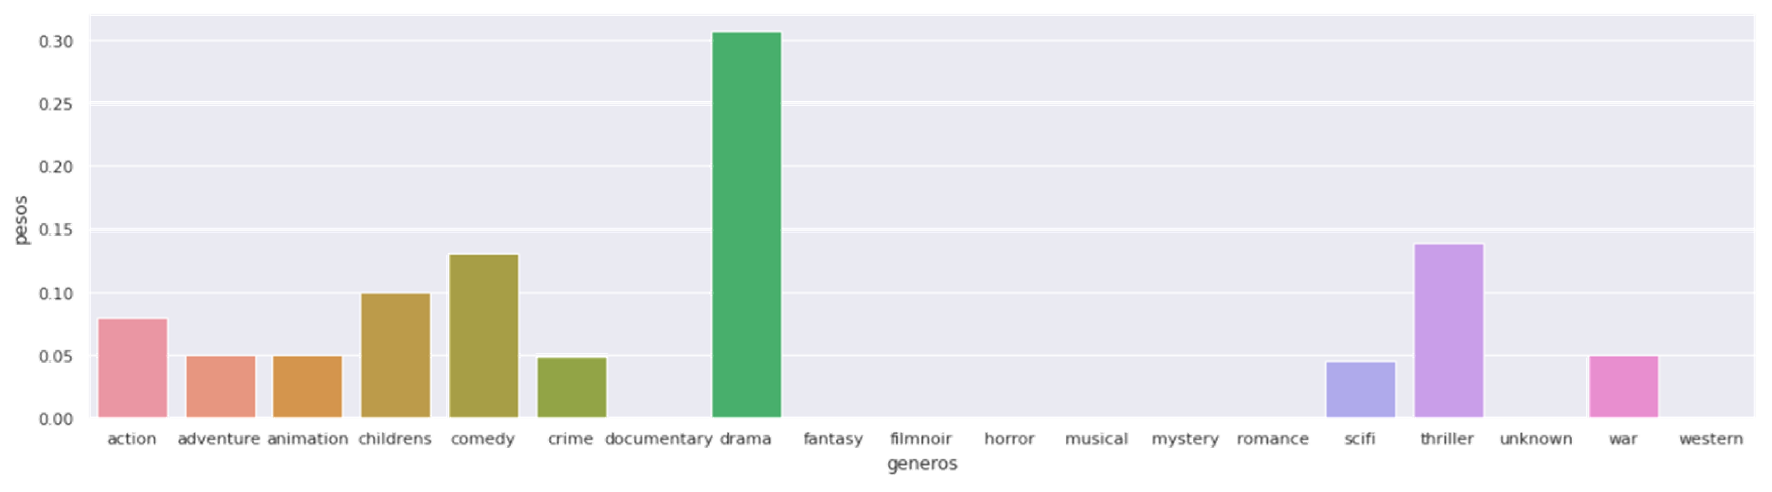

## Criação do ***user profile***

### Usar o arquivo **`ratings`** para encontrar o ***gosto*** do usuário em relação a cada gênero de filme

In [31]:
ratings.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


### Mapear as características dos filmes (ex: gêneros) a serem utilizadas na montagem do ***user profile***

In [32]:
movies.head()

,title,genres,tags,tag_count,vote_count,vote_average,imdb_score
movieId,,,,,,,
1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,fun pixar,2,215,3.920930,3.894473
2,Jumanji,Adventure|Children|Fantasy,fantasy magic_board_game game robin_williams,4,110,3.431818,3.419009
3,Grumpier Old Men,Comedy|Romance,old moldy,2,52,3.259615,3.260033
4,Waiting to Exhale,Comedy|Drama|Romance,,0,7,2.357143,2.866377
5,Father of the Bride Part II,Comedy,pregnancy remake,2,49,3.071429,3.101070


### Criar o ***user profile***

Criar o dataframe **`movie_genres`** para criaçao do ***user profile***

In [33]:
def transf(genre):
    return genre.lower().replace('(no genres listed)','unknown')


all_genres = [s.split("|") for s in movies[movies.genres.notnull()].genres]
unique_genres = sorted(set([transf(item) for l in all_genres for item in l ]))

movie_genres = movies.copy(deep=True)
movie_genres['genres'] = movie_genres.genres.str.split('|')
for g in unique_genres:
    movie_genres[g] = np.zeros(len(movie_genres))

for i, row in movie_genres.iterrows():
    for genre in row['genres']:
        movie_genres.at[i, transf(genre)] = 1

movie_genres.drop(['title','genres', 'tags', 'imdb_score','tag_count', 'vote_count', 'vote_average'], axis=1, inplace=True)
movie_genres.head(3)

,action,adventure,animation,children,comedy,crime,documentary,drama,fantasy,film-noir,horror,imax,musical,mystery,romance,sci-fi,thriller,unknown,war,western
movieId,,,,,,,,,,,,,,,,,,,,
1,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


#### Montar o ***user profile*** a partir das avaliações de um usuário

Simular as avaliações de um usuário qualquer para 3 filmes

In [34]:
user_ratings = [
            {'item':1, 'rating':3.6},
            {'item':2, 'rating':4.9},
            {'item':3, 'rating':4},
         ]

ur_df = pd.DataFrame(user_ratings)
ur_df.set_index('item', drop=True, inplace=True)
ur_df

,rating
item,
1,3.6
2,4.9
3,4.0


##### Gerar a matriz de gêneros dos filmes avaliados pelo usuário

In [35]:
userdf = movie_genres[ movie_genres.index.isin(ur_df.index) ].copy()
userdf

,action,adventure,animation,children,comedy,crime,documentary,drama,fantasy,film-noir,horror,imax,musical,mystery,romance,sci-fi,thriller,unknown,war,western
movieId,,,,,,,,,,,,,,,,,,,,
1,0.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0


##### Gerar agora a matriz de gêneros ponderada pelas avaliações do usuário


In [36]:
ur_df

,rating
item,
1,3.6
2,4.9
3,4.0


In [37]:
wgm = ur_df.values * userdf
wgm

,action,adventure,animation,children,comedy,crime,documentary,drama,fantasy,film-noir,horror,imax,musical,mystery,romance,sci-fi,thriller,unknown,war,western
movieId,,,,,,,,,,,,,,,,,,,,
1,0.0,3.6,3.6,3.6,3.6,0.0,0.0,0.0,3.6,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,4.9,0.0,4.9,0.0,0.0,0.0,0.0,4.9,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0


##### Calcular o ***user profile***

In [38]:
pd.DataFrame(wgm.sum() / wgm.values.sum()).T

,action,adventure,animation,children,comedy,crime,documentary,drama,fantasy,film-noir,horror,imax,musical,mystery,romance,sci-fi,thriller,unknown,war,western
0,0.0,0.208845,0.088452,0.208845,0.186732,0.0,0.0,0.0,0.208845,0.0,0.0,0.0,0.0,0.0,0.09828,0.0,0.0,0.0,0.0,0.0


### Função para criar o ***user_profile***

Para facilitar, vamos criar uma função para criar o ***user profile*** baseado em recomendações manuais ou já avaliadas por um usuário no arquivo ***`ratings`***


In [39]:
def create_user_profile(user=None, user_ratings=None, movie_genres=movie_genres):
    if ((user is None) & (user_ratings is None)) | ((user is not None) & (user_ratings is not None)):
        raise Exception('Necessário informar um usuário ou classificações')
    if user is not None:
        user_ratings = ratings[ ratings['userId'] == user ][['movieId', 'rating']]

    # Valida se todas as classificações são de filmes válidos
    user_ratings = user_ratings[ user_ratings.index.isin(movie_genres.index) ]

    # Calcular o peso de cada gênero para o usuário ou user_ratings
    userdf = movie_genres[ movie_genres.index.isin(user_ratings.index) ].copy()
    up = userdf.T.dot(user_ratings.rating) /  sum(userdf.T.dot(user_ratings.rating))
    return up


user_profile = create_user_profile(user_ratings=ur_df)
pd.DataFrame(user_profile).T

,action,adventure,animation,children,comedy,crime,documentary,drama,fantasy,film-noir,horror,imax,musical,mystery,romance,sci-fi,thriller,unknown,war,western
0,0.0,0.208845,0.088452,0.208845,0.186732,0.0,0.0,0.0,0.208845,0.0,0.0,0.0,0.0,0.0,0.09828,0.0,0.0,0.0,0.0,0.0


### Representação gráfica do ***user profile***

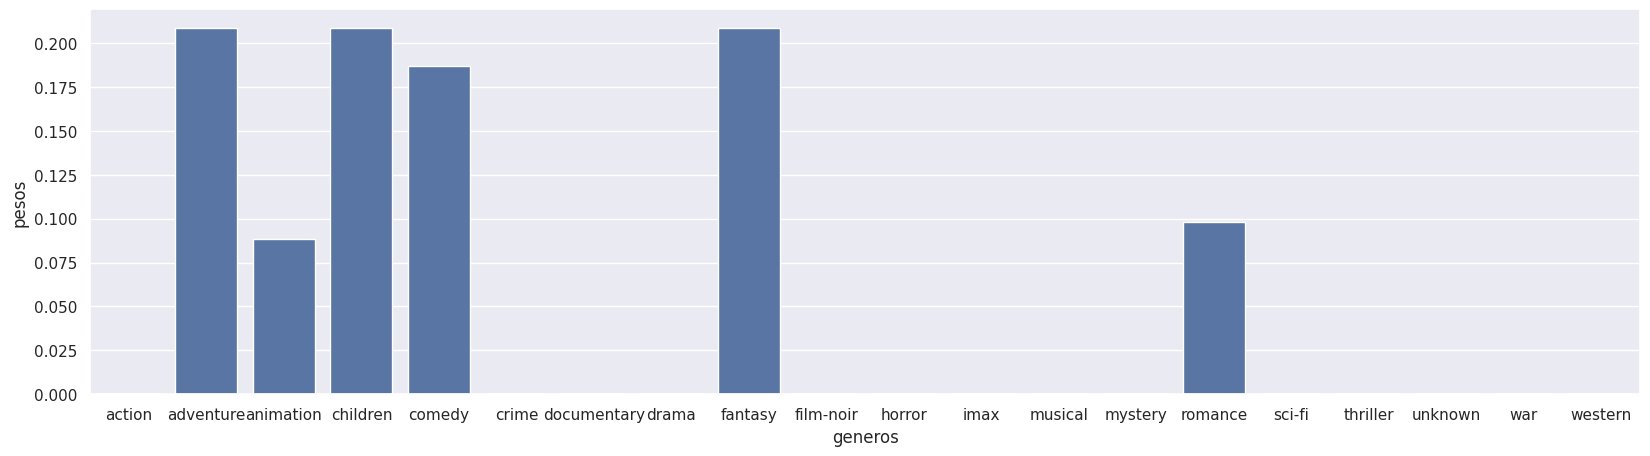

In [40]:
import seaborn as sns

def plot_user_profile(user_profile):
    genres = pd.DataFrame(zip(list(user_profile), sorted(user_profile.keys())), columns=['pesos', 'generos'])
    sns.set(rc={'figure.figsize':(20,5)})
    ax = sns.barplot(x="generos", y="pesos", data=genres)

plot_user_profile(user_profile)

##### *User profile* para um usuário específico

In [41]:
ratings[ ratings['userId'] == 1 ]

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
...,...,...,...,...
227,1,3744,4.0,964980694
228,1,3793,5.0,964981855
229,1,3809,4.0,964981220
230,1,4006,4.0,964982903


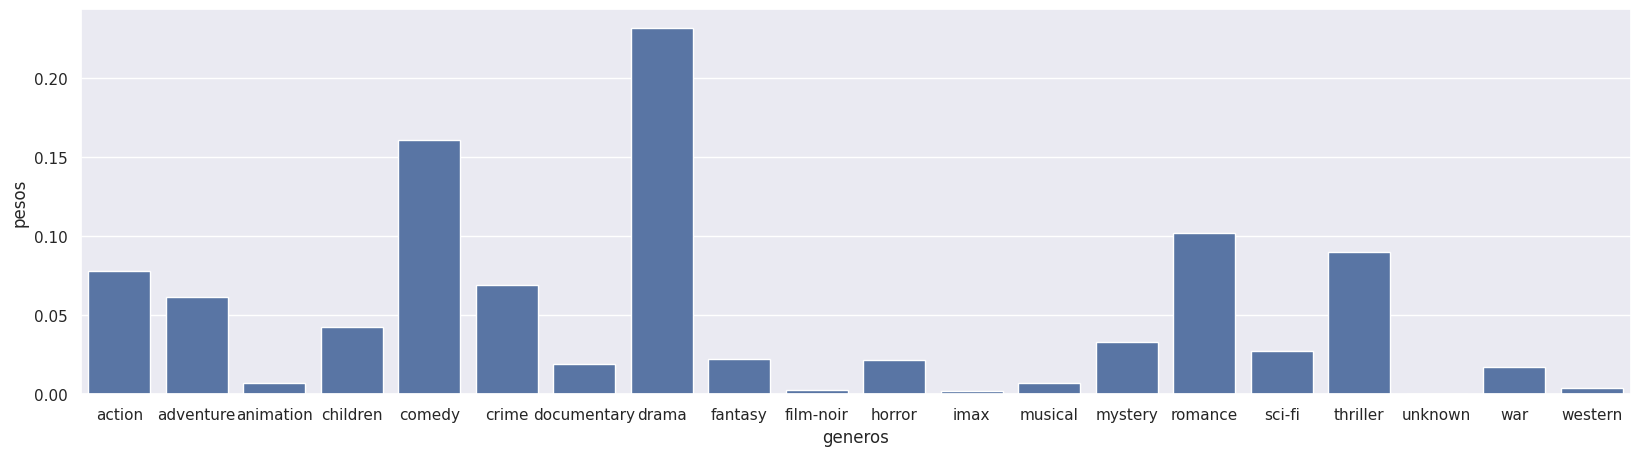

In [42]:
plot_user_profile(create_user_profile(user=1))

In [43]:
ratings[ ratings['userId'] == 404 ].head()

,userId,movieId,rating,timestamp
61353,404,11,4.0,838376006
61354,404,17,4.0,838376049
61355,404,21,3.0,838375894
61356,404,34,4.0,838375864
61357,404,36,3.0,838376195


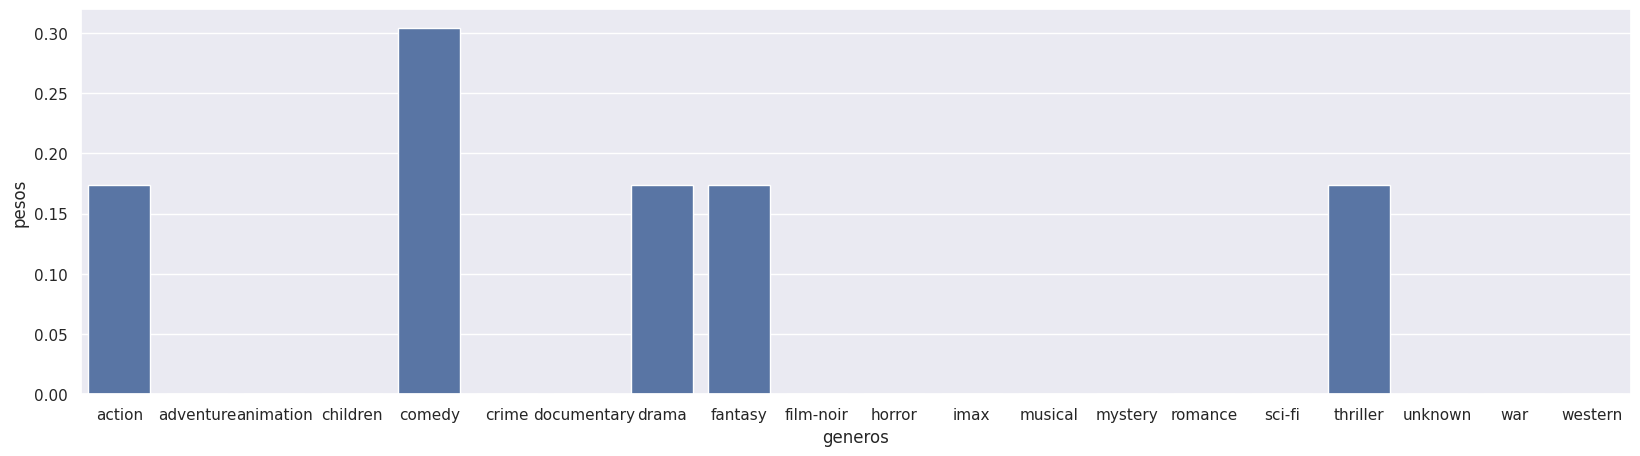

In [44]:
plot_user_profile(create_user_profile(user=404))

## Cálculo do score de cada filme de acordo com o ***user profile***

Com o ***user profile***, será possível calcular o *score* de cada filme para o usuário

### Similaridade do cosseno

In [45]:
from sklearn.metrics.pairwise import cosine_similarity

def get_movie_scores_cos(user_profile, movie_genres=movie_genres):
    movie_weights = movies.copy()
    # Calcular o score de cada filme
    movie_weights['user_profile_score'] = cosine_similarity(movie_genres.values, [user_profile.T.values])
    return movie_weights[['title', 'genres', 'imdb_score', 'user_profile_score']]

result = get_movie_scores_cos(user_profile)
result.head(5)

,title,genres,imdb_score,user_profile_score
movieId,,,,
1,Toy Story,Adventure|Animation|Children|Comedy|Fantasy,3.894473,0.942157
2,Jumanji,Adventure|Children|Fantasy,3.419009,0.845126
3,Grumpier Old Men,Comedy|Romance,3.260033,0.470853
4,Waiting to Exhale,Comedy|Drama|Romance,2.866377,0.384450
5,Father of the Bride Part II,Comedy,3.101070,0.436270


### Recomendações baseadas no ***user profile***

Criar a função **`get_user_profile_recommendations()`** para encontrar recomendações baseadas no ***user profile***

In [46]:
def get_user_profile_recommendations(user=None, topN=10):

    # Se informar o usuário, cria o user_profile
    user_profile = create_user_profile(user=user)

    aux = get_movie_scores_cos(user_profile)
    # Desconsidera os filmes já avaliados pelo usuário
    aux = aux[ ~aux.index.isin(ratings[ ratings['userId'] == user ].movieId.values) ]

    return aux.sort_values(by=['user_profile_score', 'imdb_score'], ascending=False).head(topN)


##### Recomendações para um usuário

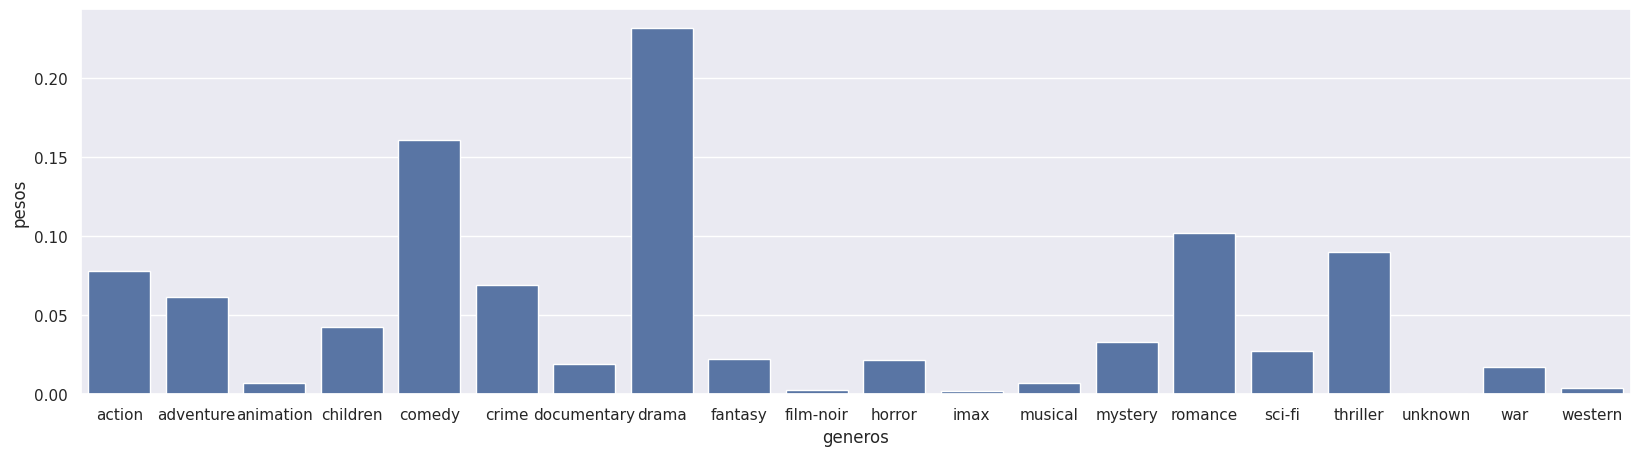

In [47]:
plot_user_profile(create_user_profile(user=1))

In [48]:
get_user_profile_recommendations(user=1)

,title,genres,imdb_score,user_profile_score
movieId,,,,
4956,"Stunt Man, The",Action|Adventure|Comedy|Drama|Romance|Thriller,3.571836,0.859943
1912,Out of Sight,Comedy|Crime|Drama|Romance|Thriller,3.728342,0.850166
144606,Confessions of a Dangerous Mind,Comedy|Crime|Drama|Romance|Thriller,3.336203,0.850166
3893,Nurse Betty,Comedy|Crime|Drama|Romance|Thriller,3.316501,0.850166
496,What Happened Was...,Comedy|Drama|Romance|Thriller,3.436203,0.850136
5666,"Rules of Attraction, The",Comedy|Drama|Romance|Thriller,3.383002,0.850136
72142,Love Exposure (Ai No Mukidashi),Action|Comedy|Drama|Romance,3.436203,0.833148
898,"Philadelphia Story, The",Comedy|Drama|Romance,4.062159,0.830971
1235,Harold and Maude,Comedy|Drama|Romance,4.024630,0.830971


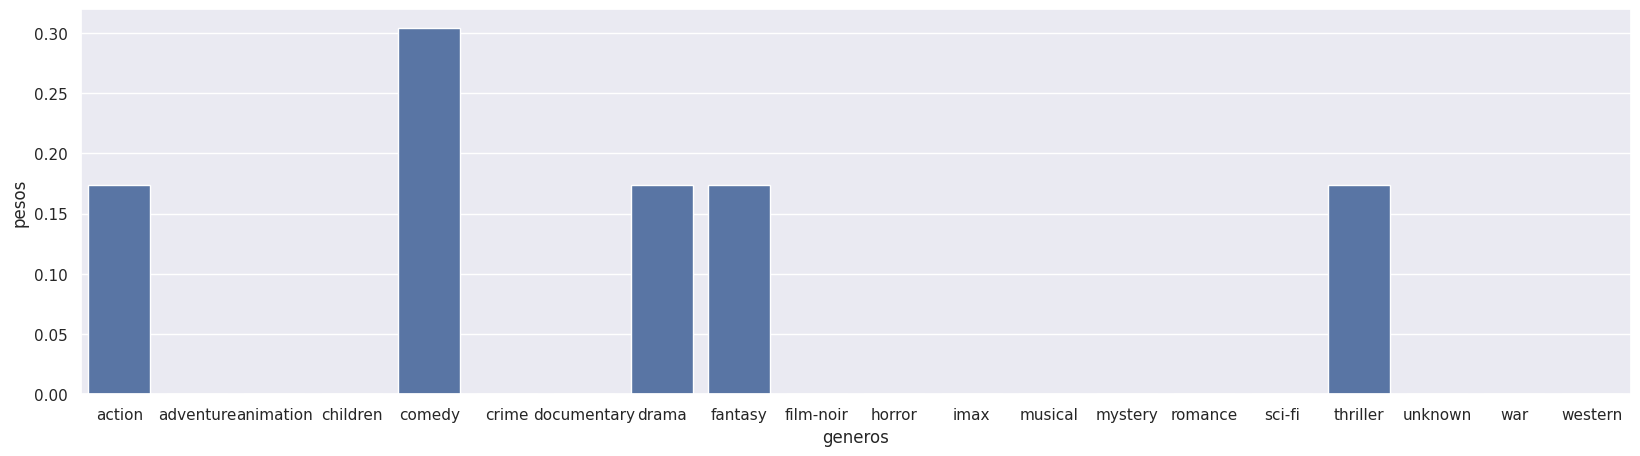

In [49]:
plot_user_profile(create_user_profile(user=404))

In [50]:
get_user_profile_recommendations(user=404)

,title,genres,imdb_score,user_profile_score
movieId,,,,
70728,Bronson,Action|Comedy|Drama|Thriller,3.405170,0.893685
59947,"Protector, The",Action|Comedy|Drama|Thriller,3.136203,0.893685
61401,"Spirit, The",Action|Comedy|Fantasy|Thriller,3.123821,0.893685
117646,Dragonheart 2: A New Beginning,Action|Adventure|Comedy|Drama|Fantasy|Thriller,3.386203,0.883310
2997,Being John Malkovich,Comedy|Drama|Fantasy,3.896871,0.814688
116897,Wild Tales,Comedy|Drama|Thriller,3.782212,0.814688
6666,"Discreet Charm of the Bourgeoisie, The (Charme...",Comedy|Drama|Fantasy,3.633002,0.814688
319,Shallow Grave,Comedy|Drama|Thriller,3.495243,0.814688
1112,Palookaville,Action|Comedy|Drama,3.487458,0.814688


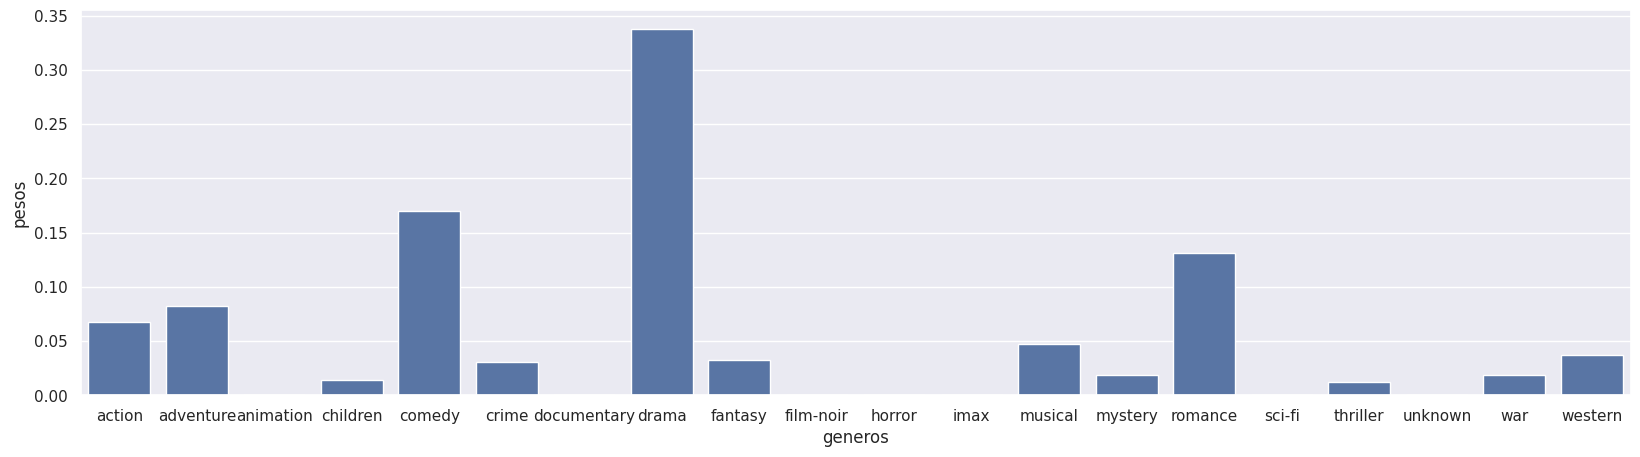

In [51]:
plot_user_profile(create_user_profile(user=48))

In [52]:
get_user_profile_recommendations(user=48)

,title,genres,imdb_score,user_profile_score
movieId,,,,
898,"Philadelphia Story, The",Comedy|Drama|Romance,4.062159,0.87398
1235,Harold and Maude,Comedy|Drama|Romance,4.024630,0.87398
1247,"Graduate, The",Comedy|Drama|Romance,3.981387,0.87398
6711,Lost in Translation,Comedy|Drama|Romance,3.950145,0.87398
1244,Manhattan,Comedy|Drama|Romance,3.925287,0.87398
58,"Postman, The (Postino, Il)",Comedy|Drama|Romance,3.877436,0.87398
916,Roman Holiday,Comedy|Drama|Romance,3.853201,0.87398
5902,Adaptation,Comedy|Drama|Romance,3.833855,0.87398
88163,"Crazy, Stupid, Love.",Comedy|Drama|Romance,3.821551,0.87398
